Cell 1: Imports

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sns.set_style("whitegrid")
# pd.set_option("display.max_columns", 200)

Cell 2: Load model

In [2]:
xgb_model = joblib.load("data/models/xgb_temporal.joblib")
print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


Cell 3: Load temporal dataset

In [5]:
feature_df = pd.read_parquet("data/processed/feature_df.parquet")  # change path if needed
feature_df["day"] = pd.to_datetime(feature_df["day"], errors="coerce")
feature_df = feature_df.sort_values(["day", "user"]).reset_index(drop=True)

print(feature_df.shape)

(1394010, 55)


Cell 4: Set columns

In [9]:
from sklearn.model_selection import GroupShuffleSplit


TARGET_COL = "is_insider"
GROUP_COL = "user"
TIME_COL = "day"

leak_cols = [
    "after_hours_events",
    "user_mean_after",
    "user_std_after",
    "after_hours_events_dev",
    "after_hours_ratio",
]
mean_std_cols = [c for c in feature_df.columns if c.startswith("user_mean_") or c.startswith("user_std_")]
# drop_cols = list(set(leak_cols + mean_std_cols + ["user", "day", "employee_name", "email", "projects"]))
drop_cols = list(set(leak_cols + mean_std_cols + ["user", "day", "employee_name", "email", "projects", "total_events"]))

feature_cols = [c for c in feature_df.columns if c not in drop_cols]

X = feature_df[feature_cols].copy()
y = feature_df[TARGET_COL].copy()
groups = feature_df[GROUP_COL].copy()

print("Number of features:", len(feature_cols))
print(feature_cols[:20])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(feature_df, feature_df["is_insider"], groups=groups))

Number of features: 28
['logon_count', 'file_count', 'email_count', 'device_count', 'http_count', 'role', 'functional_unit', 'department', 'team', 'supervisor', 'is_insider', 'unique_pcs', 'first_hour', 'last_hour', 'device_events', 'email_events', 'file_events', 'http_events', 'logon_events', 'total_events_dev']


Cell 5: Load X_train, X_test, y_train, y_test datasets

In [13]:
X_train = pd.read_parquet("data/processed/X_train.parquet")
y_train = pd.read_csv("data/processed/y_train.csv").squeeze("columns")
X_test = pd.read_parquet("data/processed/X_test.parquet")
y_test = pd.read_csv("data/processed/y_test.csv").squeeze("columns")

X_train = X_train.drop(columns='total_events')
X_test = X_test.drop(columns='total_events')

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("Train target distribution:\n", y_train.value_counts())
print("Test target distribution:\n", y_test.value_counts())

X_train: (1115208, 434)
y_train: (1115208,)
X_test : (278802, 434)
y_test : (278802,)
Train target distribution:
 is_insider
0    1115202
1          6
Name: count, dtype: int64
Test target distribution:
 is_insider
0    278783
1        19
Name: count, dtype: int64


Cell 6: Predict probabilities

In [14]:
y_score = xgb_model.predict_proba(X_test)[:, 1]

topk_df = X_test.copy()
topk_df[TARGET_COL] = y_test.values
topk_df["pred_proba"] = y_score
topk_df["rank"] = topk_df["pred_proba"].rank(method="first", ascending=False).astype(int)

topk_df = topk_df.sort_values("pred_proba", ascending=False).reset_index(drop=True)
topk_df.head(10)

,logon_count,file_count,email_count,device_count,http_count,unique_pcs,first_hour,last_hour,device_events,email_events,...,supervisor_Zelda Aretha Wallace,supervisor_Zelda Idona Ross,supervisor_Zelda Jescie Atkinson,supervisor_Zelda Zelenia Owens,supervisor_Zenaida Carol Snow,supervisor_Zenia Basia Whitley,supervisor_Zephania Chaim Terry,is_insider,pred_proba,rank
0,3,3,16,10,172,1.0,11.0,17.0,0.0,0.0,...,False,False,False,False,False,False,False,1,0.986214,1
1,3,2,16,10,167,1.0,15.0,17.0,0.0,0.0,...,False,False,False,False,False,False,False,1,0.986214,2
2,3,6,19,10,173,1.0,9.0,17.0,0.0,3.0,...,False,False,False,False,False,False,False,1,0.985721,4
3,3,2,18,10,171,1.0,9.0,17.0,0.0,2.0,...,False,False,False,False,False,False,False,1,0.985721,5
4,3,10,17,10,166,1.0,9.0,17.0,0.0,1.0,...,False,False,False,False,False,False,False,1,0.985721,3
5,4,2,16,10,171,1.0,10.0,17.0,0.0,0.0,...,False,False,False,False,False,False,False,1,0.984825,6
6,3,10,16,10,162,1.0,17.0,17.0,10.0,0.0,...,False,False,False,False,False,False,False,0,0.971880,8
7,3,6,16,12,162,1.0,9.0,16.0,12.0,0.0,...,False,False,False,False,False,False,False,0,0.971880,7
8,5,1,16,10,170,1.0,9.0,17.0,0.0,0.0,...,False,False,False,False,False,False,False,1,0.971091,9
9,3,3,17,12,162,1.0,9.0,17.0,12.0,1.0,...,False,False,False,False,False,False,False,0,0.970890,10


Cell 7: Top-k metrics function

In [15]:
def compute_topk_metrics(df_scored, target_col, score_col, k_list):
    df_sorted = df_scored.sort_values(score_col, ascending=False).reset_index(drop=True)
    total_positives = df_sorted[target_col].sum()
    base_rate = df_sorted[target_col].mean()
    
    rows = []
    
    for k in k_list:
        top_k = df_sorted.head(k)
        hits = int(top_k[target_col].sum())
        precision_at_k = hits / k if k > 0 else 0.0
        recall_at_k = hits / total_positives if total_positives > 0 else 0.0
        lift_at_k = precision_at_k / base_rate if base_rate > 0 else np.nan
        
        rows.append({
            "k": k,
            "hits_at_k": hits,
            "precision_at_k": precision_at_k,
            "recall_at_k": recall_at_k,
            "lift_at_k": lift_at_k
        })
    
    return pd.DataFrame(rows)

Cell 8: Choose K values

In [16]:
k_list = [5, 10, 20, 50, 100, 200, 500]
topk_results = compute_topk_metrics(topk_df, TARGET_COL, "pred_proba", k_list)
topk_results

,k,hits_at_k,precision_at_k,recall_at_k,lift_at_k
0,5,5,1.000,0.263158,14673.789474
1,10,7,0.700,0.368421,10271.652632
2,20,16,0.800,0.842105,11739.031579
3,50,19,0.380,1.000000,5576.040000
4,100,19,0.190,1.000000,2788.020000
5,200,19,0.095,1.000000,1394.010000
6,500,19,0.038,1.000000,557.604000


Cell 9: Cumulative recall curve

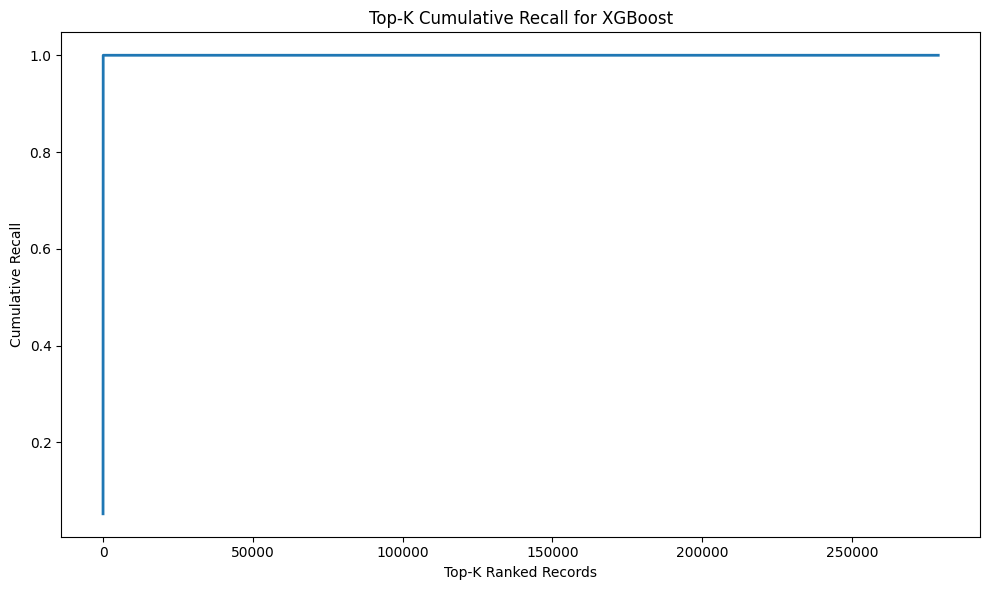

In [17]:
topk_df["cum_hits"] = topk_df[TARGET_COL].cumsum()
total_positives = topk_df[TARGET_COL].sum()
topk_df["cum_recall"] = topk_df["cum_hits"] / total_positives if total_positives > 0 else 0

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(topk_df) + 1), topk_df["cum_recall"], linewidth=2)
plt.xlabel("Top-K Ranked Records")
plt.ylabel("Cumulative Recall")
plt.title("Top-K Cumulative Recall for XGBoost")
plt.tight_layout()
plt.show()

Cell 10: Precision@K plot

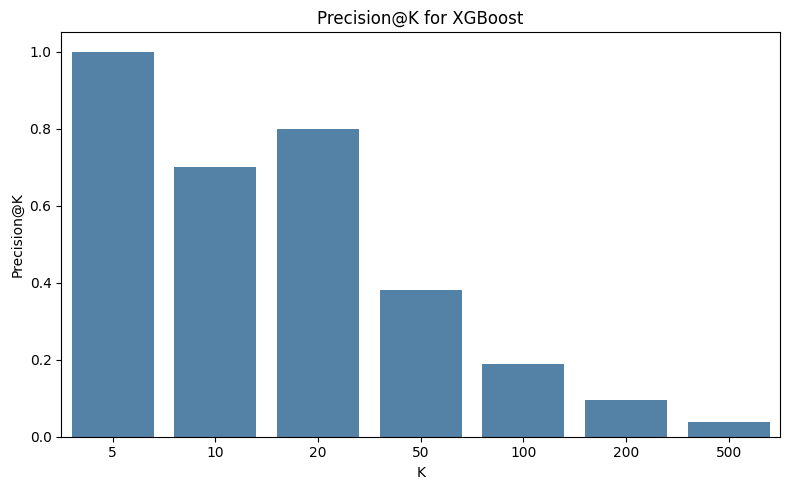

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(data=topk_results, x="k", y="precision_at_k", color="steelblue")
plt.title("Precision@K for XGBoost")
plt.ylabel("Precision@K")
plt.xlabel("K")
plt.tight_layout()
plt.show()

Cell 11: Recall@K plot

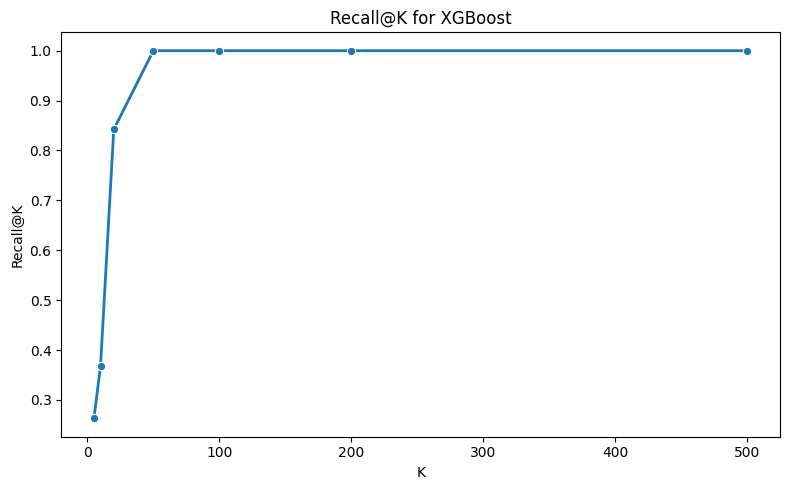

In [19]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=topk_results, x="k", y="recall_at_k", marker="o", linewidth=2)
plt.title("Recall@K for XGBoost")
plt.ylabel("Recall@K")
plt.xlabel("K")
plt.tight_layout()
plt.show()

Cell 12: Lift@K plot

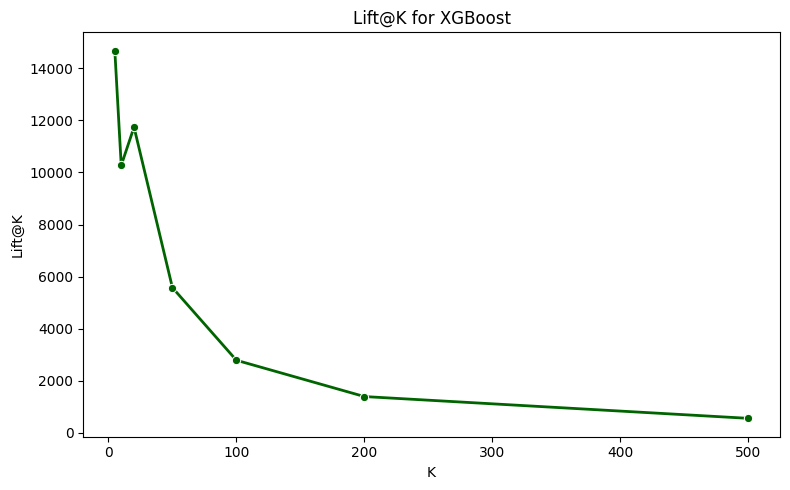

In [20]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=topk_results, x="k", y="lift_at_k", marker="o", linewidth=2, color="darkgreen")
plt.title("Lift@K for XGBoost")
plt.ylabel("Lift@K")
plt.xlabel("K")
plt.tight_layout()
plt.show()

Cell 13: Inspect top flagged records

In [21]:
# cols_to_show = ["pred_proba", TARGET_COL]
# extra_cols = [c for c in [GROUP_COL, TIME_COL] if c in top_records.columns]

top_records = topk_df.reset_index(drop=True).copy()

# if GROUP_COL in feature_df.columns:
#     top_records[GROUP_COL] = feature_df.iloc[test_idx][GROUP_COL].values

# if TIME_COL in feature_df.columns:
#     top_records[TIME_COL] = feature_df.iloc[test_idx][TIME_COL].values

# top_records[extra_cols + cols_to_show].head(20)

cols_to_show = ["pred_proba", TARGET_COL]
display_cols = [c for c in [GROUP_COL, TIME_COL] if c in top_records.columns] + cols_to_show
top_records[display_cols].head(20)

,pred_proba,is_insider
0,0.986214,1
1,0.986214,1
2,0.985721,1
3,0.985721,1
4,0.985721,1
5,0.984825,1
6,0.971880,0
7,0.971880,0
8,0.971091,1
9,0.970890,0


Cell 14: Summary statements

In [22]:
topk_results_rounded = topk_results.copy()
for col in ["precision_at_k", "recall_at_k", "lift_at_k"]:
    topk_results_rounded[col] = topk_results_rounded[col].round(4)

topk_results_rounded

,k,hits_at_k,precision_at_k,recall_at_k,lift_at_k
0,5,5,1.000,0.2632,14673.7895
1,10,7,0.700,0.3684,10271.6526
2,20,16,0.800,0.8421,11739.0316
3,50,19,0.380,1.0000,5576.0400
4,100,19,0.190,1.0000,2788.0200
5,200,19,0.095,1.0000,1394.0100
6,500,19,0.038,1.0000,557.6040


Cell 15: Save outputs

In [23]:
topk_results.to_csv("data/processed/topk_results_xgb.csv", index=False)
topk_df.to_csv("data/processed/topk_ranked_predictions_xgb.csv", index=False)

print("Saved top-k results and ranked predictions.")

Saved top-k results and ranked predictions.
